In [2]:
# ЗАПУСТИ МЕНЯ
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [3]:
pip install -U bitsandbytes>=0.46.1 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [4]:
pip install bert_score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install kvpress -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you have numba-cuda 0.30.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [10]:
import gc
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Optional, Tuple

from tqdm import tqdm

import torch
import torch.nn.functional as F

import evaluate
from evaluate import load

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, DynamicCache
from kvpress import ObservedAttentionPress, DecodingPress, PrefillDecodingPress

## Обычный KV cache

In [5]:
model_name = "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [32]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

In [7]:
rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

In [40]:
def inference(input_size, dataset, model, tokenizer, max_new_tokens=512):
    predicted = []
    ground_truth = []
    speeds = []
    decode_latencies = [] 
    total_times = []    
    memory_after_inference = []

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    
    baseline_memory = torch.cuda.memory_allocated() / 1024**2

    for sample in tqdm(dataset, desc="Генерация суммаризаций"):
        messages = [
            {"role": "system", "content": "You are a helpful assistant that summarizes book chapters."},
            {"role": "user", "content": f"Summarize the following chapter concisely:\n\n{sample['chapter'][:input_size]}"}
        ]

        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt"
        )

        if not isinstance(inputs, torch.Tensor):
            inputs = inputs["input_ids"]

        inputs = inputs.to(model.device)

        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        with torch.no_grad():
            start_event.record()
            
            outputs = model.generate(
                inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )
            
            end_event.record()
            torch.cuda.synchronize()
            
            total_time_ms = start_event.elapsed_time(end_event)
            total_times.append(total_time_ms / 1000) 

        generated_text = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

        tokens_generated = outputs.shape[1] - inputs.shape[1]
        
        # === РАСЧЁТ МЕТРИК ===
        
        # Общая скорость (tokens/sec)
        total_time_sec = total_time_ms / 1000
        speed = tokens_generated / total_time_sec if total_time_sec > 0 else 0.0
        speeds.append(speed)
        
        decode_latency_ms = total_time_ms / tokens_generated if tokens_generated > 0 else 0.0
        decode_latencies.append(decode_latency_ms)

        torch.cuda.synchronize()
        mem_after = torch.cuda.max_memory_allocated() / 1024**2
        memory_after_inference.append(mem_after - baseline_memory)

        predicted.append(generated_text)
        ground_truth.append(sample['summary'])
        
        del outputs
        torch.cuda.empty_cache()

    # === УСРЕДНЕНИЕ ===
    avg_speed = sum(speeds) / len(speeds) if speeds else 0.0
    avg_decode_latency_ms = sum(decode_latencies) / len(decode_latencies) if decode_latencies else 0.0
    avg_total_time = sum(total_times) / len(total_times) if total_times else 0.0
    avg_memory_after_inference = sum(memory_after_inference) / len(memory_after_inference) if memory_after_inference else 0.0

    return predicted, ground_truth, avg_speed, avg_memory_after_inference, avg_decode_latency_ms

In [16]:
def get_metrics(predicted, ground_truth):
    rouge_scores = rouge.compute(predictions=predicted, references=ground_truth)
    
    bert_scores = bertscore.compute(
        predictions=predicted, 
        references=ground_truth, 
        lang="en",
        model_type="roberta-large"
    )
    
    bert_precision = sum(bert_scores['precision']) / len(bert_scores['precision'])
    bert_recall = sum(bert_scores['recall']) / len(bert_scores['recall'])
    bert_f1 = sum(bert_scores['f1']) / len(bert_scores['f1'])
    
    return {
        'rouge1': rouge_scores['rouge1'],
        'rouge2': rouge_scores['rouge2'],
        'rougeL': rouge_scores['rougeL'],
        'rougeLsum': rouge_scores['rougeLsum'],
        'bert_precision': bert_precision,
        'bert_recall': bert_recall,
        'bert_f1': bert_f1
    }

In [35]:
def run_experiment(experiment_name, input_size, kv_cache_type, dataset, model, tokenizer):
    print(f"\n{'='*60}")
    print(f"Запуск эксперимента: {experiment_name}")
    print(f"Тип KV cache: {kv_cache_type}")
    print(f"{'='*60}\n")
    
    predicted, ground_truth, avg_speed, avg_memory, avg_decode_latency_ms = inference(
        input_size, dataset, model, tokenizer, max_new_tokens=512
    )
    
    # Расчет метрик
    metrics = get_metrics(predicted, ground_truth)
    
    print(f"\nРезультаты эксперимента:")
    print(f"Средняя скорость генерации: {avg_speed:.2f} токенов/сек")
    print(f"Средние затраты памяти: {avg_memory:.2f} MB")
    print(f"ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"ROUGE-L: {metrics['rougeL']:.4f}")
    print(f"BERTScore F1: {metrics['bert_f1']:.4f}")
    
    # Создаем строку для DataFrame
    result_row = {
        'experiment_name': experiment_name,
        'kv_cache_type': kv_cache_type,
        'rouge1': metrics['rouge1'],
        'rouge2': metrics['rouge2'],
        'rougeL': metrics['rougeL'],
        'rougeLsum': metrics['rougeLsum'],
        'bert_f1': metrics['bert_f1'],
        'generation_speed': avg_speed,
        'memory_usage_mb': avg_memory,
        'decode_latency_ms': avg_decode_latency_ms
    }
    
    return result_row

In [ ]:
dataset  = load_dataset("kmfoda/booksum", split="test")

In [45]:
dataset_subset = dataset.select(range(50))
input_size = 16384

result = run_experiment(
    experiment_name="Baseline with KV cache",
    input_size=input_size,
    kv_cache_type="vanile",
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)


# Создаем DataFrame
df = pd.DataFrame([result])


print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: Baseline with KV cache
Тип KV cache: vanile



Генерация суммаризаций: 100%|██████████| 50/50 [27:24<00:00, 32.89s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.51 токенов/сек
Средние затраты памяти: 4774.54 MB
ROUGE-1: 0.2312
ROUGE-2: 0.0299
ROUGE-L: 0.1105
BERTScore F1: 0.8227

Итоговая таблица результатов:
       experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
Baseline with KV cache        vanile 0.231186 0.029941 0.110517   0.128849 0.822689          7.506506      4774.538867         134.520516


In [46]:
dataset_subset = dataset.select(range(50))
input_size = 8192

result = run_experiment(
    experiment_name="Baseline with KV cache",
    input_size=input_size,
    kv_cache_type="vanile",
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)


# Создаем DataFrame
df = pd.DataFrame([result])


print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: Baseline with KV cache
Тип KV cache: vanile



Генерация суммаризаций: 100%|██████████| 50/50 [22:39<00:00, 27.20s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.79 токенов/сек
Средние затраты памяти: 1312.82 MB
ROUGE-1: 0.2165
ROUGE-2: 0.0271
ROUGE-L: 0.1052
BERTScore F1: 0.8226

Итоговая таблица результатов:
       experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
Baseline with KV cache        vanile 0.216515 0.027061 0.105196   0.115962 0.822562          7.791527      1312.824883         128.504803


In [47]:
dataset_subset = dataset.select(range(50))
input_size = 4096

result = run_experiment(
    experiment_name="Baseline with KV cache",
    input_size=input_size,
    kv_cache_type="vanile",
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)


# Создаем DataFrame
df = pd.DataFrame([result])


print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: Baseline with KV cache
Тип KV cache: vanile



Генерация суммаризаций: 100%|██████████| 50/50 [18:31<00:00, 22.24s/it]



Результаты эксперимента:
Средняя скорость генерации: 8.21 токенов/сек
Средние затраты памяти: 397.00 MB
ROUGE-1: 0.2061
ROUGE-2: 0.0266
ROUGE-L: 0.1018
BERTScore F1: 0.8234

Итоговая таблица результатов:
       experiment_name kv_cache_type   rouge1  rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
Baseline with KV cache        vanile 0.206088 0.02656 0.101832   0.108494  0.82339          8.213354       396.995156         121.773318


In [30]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Всего памяти: {torch.cuda.get_device_properties(0).total_memory / 1024**2:.2f} MB")
    print(f"Выделено памяти: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Зарезервировано: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
    print(f"Свободно: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**2:.2f} MB")
else:
    print("CUDA недоступна")

GPU: Tesla T4
Всего памяти: 14911.69 MB
Выделено памяти: 2277.75 MB
Зарезервировано: 4914.00 MB
Свободно: 12633.94 MB


In [29]:
import torch
import gc

# Очистка кэша PyTorch
torch.cuda.empty_cache()

# Сборка мусора Python
gc.collect()

# Сброс статистики памяти
torch.cuda.reset_peak_memory_stats()
torch.cuda.reset_accumulated_memory_stats()

print("Память GPU очищена!")
print(f"Текущая память: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Максимальная память: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")

Память GPU очищена!
Текущая память: 2277.75 MB
Максимальная память: 2277.75 MB


## Добавляем SnapKV с учетом архитектуры GQA и attention_sinks

In [18]:
class SnapKVCache:
    """
    SnapKV с учетом attention sink tokens.
    """
    
    def __init__(
        self,
        observation_window: int = 64, # из статьи
        final_cache_size: int = 512,
        sink_token_length: int = 4, # в статье упоминаются attention_sink, но при этом их реализации нет, их можно убрать сделав = 0
    ):
        self.observation_window = observation_window
        # self.compression_ratio = compression_ratio
        self.final_cache_size = final_cache_size
        self.sink_token_length = sink_token_length

    def _repeat_kv_for_gqa(
        self, 
        key_states: torch.Tensor,
        n_rep: int
    ) -> torch.Tensor:
        """
        Повторяет key/value тензоры для согласования числа голов запроса и ключа.
        Формат: [batch, num_kv_heads, seq_len, head_dim] -> [batch, num_heads, seq_len, head_dim]
        n_rep = num_heads // num_kv_heads
        """
        if n_rep == 1:
            return key_states
        batch, num_kv_heads, seq_len, head_dim = key_states.shape
        # хардкодим копирование key-value для GQA
        key_states = key_states[:, :, None, :, :].expand(
            batch, num_kv_heads, n_rep, seq_len, head_dim
        )
        
        return key_states.reshape(batch, num_kv_heads * n_rep, seq_len, head_dim) # batch x num_kv_heads x n_rep x seq_len x head_dim -> batch x num_kv_heads * n_rep x seq_len x head_dim
        
    def compute_importance_scores(
        self,
        query_states: torch.Tensor,
        key_states: torch.Tensor,
        seq_len: int
    ) -> torch.Tensor:
        """
        Args:
            query_states: [batch, num_heads, full_seq_len, head_dim]
            key_states:   [batch, num_kv_heads, full_seq_len, head_dim]
        Returns:
            importance_scores: [batch, full_seq_len]  (усреднённые по всем головам)
        """
        batch_size, num_heads, _, head_dim = query_states.shape
        num_kv_heads = key_states.shape[1]

        # приседания с количеством q в одной группе (для GQA)
        n_rep = num_heads // num_kv_heads
        key_states_expanded = self._repeat_kv_for_gqa(key_states, n_rep)

        q_obs = query_states[:, :, -self.observation_window:, :]        # [B, H, obs, D]

        k_prefix = key_states_expanded[:, :, :seq_len - self.observation_window, :]  # [B, H, prefix, D]

        scale = 1.0 / math.sqrt(head_dim)
        attn_scores = torch.matmul(q_obs, k_prefix.transpose(-2, -1)) * scale  # [B, H, obs, prefix]

        importance_scores = attn_scores.sum(dim=2)
        importance_scores = importance_scores.sum(dim=1) # возможно тут надо использовать mean, но пока попробуем с sum

        return importance_scores
    
    def select_important_tokens(
        self,
        importance_scores: torch.Tensor,
        seq_len: int
    ) -> torch.Tensor:

        batch_size = importance_scores.shape[0]
        
        scores = importance_scores.unsqueeze(1)
        pooled_scores = F.avg_pool1d( # bs x 1 x prefix_size
            scores,
            kernel_size=5,
            stride=1,
            padding= 5 // 2
        ).squeeze(1) # bs x prefix_size
        
        num_to_keep = min(self.final_cache_size, seq_len)
        
        exclude_mask = torch.ones_like(pooled_scores, dtype=torch.bool)
        exclude_mask[:, :self.sink_token_length] = False

        masked_scores = pooled_scores.clone()
        masked_scores[~exclude_mask] = float('-inf')
        
        num_from_middle = num_to_keep - self.sink_token_length - self.observation_window
        num_from_middle = max(0, num_from_middle)
        
        _, selected_indices = torch.topk(masked_scores, num_from_middle, dim=-1)
        
        # attention_sink_tokens
        sink_tokens = torch.arange(
            0,
            self.sink_token_length,
            device=selected_indices.device
        ).unsqueeze(0).expand(batch_size, -1)
        
        # obs_window
        observation_tokens = torch.arange(
            seq_len - self.observation_window,
            seq_len,
            device=selected_indices.device
        ).unsqueeze(0).expand(batch_size, -1)
        
        combined_indices = torch.cat([
            sink_tokens,        # attention_sink_tokens
            selected_indices,   # important_tokens
            observation_tokens  # closest_tokens
        ], dim=-1)
        
        combined_indices = torch.unique(combined_indices, dim=-1)
        combined_indices, _ = torch.sort(combined_indices, dim=-1)
        
        return combined_indices
    
    def compress_kv_cache(
        self,
        key_states: torch.Tensor,
        value_states: torch.Tensor,
        selected_indices: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Сжимает KV cache, оставляя только те токены, что набрали в select_important_tokens
        
        Args:
            key_states: [batch, num_kv_heads, seq_len, head_dim]
            value_states: [batch, num_kv_heads, seq_len, head_dim]
            selected_indices: [batch, num_selected]
        
        Returns:
            compressed_keys: [batch, num_kv_heads, num_selected, head_dim]
            compressed_values: [batch, num_kv_heads, num_selected, head_dim]
        """
        batch_size, num_kv_heads, seq_len, head_dim = key_states.shape
        
        compressed_keys = []
        compressed_values = []
        
        for b in range(batch_size):
            indices = selected_indices[b]
            
            # [num_kv_heads, num_selected, head_dim]
            k = key_states[b, :, indices, :]
            v = value_states[b, :, indices, :]
            
            compressed_keys.append(k)
            compressed_values.append(v)
        
        compressed_keys = torch.stack(compressed_keys, dim=0)
        compressed_values = torch.stack(compressed_values, dim=0)
        
        return compressed_keys, compressed_values

In [6]:
class SnapKVAttentionWrapper:
    def __init__(self, model, tokenizer, snapkv_config):
        self.model = model
        self.tokenizer = tokenizer
        self.snapkv = snapkv_config
        self.compressed_kv_cache = None

    def prefill_with_compression(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.shape

        with torch.no_grad():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                use_cache=True,
                output_hidden_states=True,
                return_dict=True,
            )

        past_key_values = outputs.past_key_values 
        hidden_states = outputs.hidden_states 
        logits = outputs.logits[:, -1:, :].clone()

        compressed_cache_object = DynamicCache()
        
        for layer_idx in range(len(past_key_values.layers)):
            key_states, value_states = past_key_values.layers[layer_idx].keys, past_key_values.layers[layer_idx].values

            layer_input = hidden_states[layer_idx]   # [B, full_len, hidden_dim]

            query_states = self._compute_query_states(layer_input, layer_idx)

            importance = self.snapkv.compute_importance_scores(
                query_states, key_states, seq_len
            )
            selected_indices = self.snapkv.select_important_tokens(
                importance, seq_len
            )
            comp_k, comp_v = self.snapkv.compress_kv_cache(
                key_states, value_states, selected_indices
            )
            compressed_cache_object.update(comp_k, comp_v, layer_idx)

            del key_states, value_states, layer_input, query_states
            del importance, selected_indices, comp_k, comp_v
        
        self.compressed_kv_cache = compressed_cache_object

        del outputs, past_key_values, hidden_states
        torch.cuda.empty_cache()
        gc.collect()
        
        return logits

    def _compute_query_states(self, hidden_states, layer_idx):
        num_heads = getattr(self.model.config, "num_attention_heads")
        head_dim = getattr(self.model.config, "head_dim", None)
        
        layer = self.model.model.layers[layer_idx].self_attn
        q = layer.q_proj(hidden_states)                     # b x seq_len x num_heads*head_dim
        q = q.view(q.size(0), q.size(1), num_heads, head_dim)
        return q.transpose(1, 2)                            # b x num_heads x seq_len x head_dim

    def generate_with_compressed_cache(self, input_ids, max_new_tokens=256, **kwargs):
        next_input_ids = input_ids[:, -1:] 
        
        compressed_seq_len = self.compressed_kv_cache.layers[0].keys.shape[2] 
    
        batch_size = next_input_ids.shape[0]
        device = next_input_ids.device
        new_attention_mask = torch.ones((batch_size, compressed_seq_len + 1), device=device, dtype=torch.long)
        cache_position = torch.tensor([compressed_seq_len], device=device, dtype=torch.long)
        
        return self.model.generate(
            input_ids=next_input_ids,
            attention_mask=new_attention_mask,
            past_key_values=self.compressed_kv_cache,
            cache_position=cache_position,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            **kwargs,
        )

In [7]:
model_name = "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

In [25]:
def inference_snapkv(input_size, dataset, model, tokenizer, snapkv_config, max_new_tokens=512):
    predicted = []
    ground_truth = []
    speeds = []
    prefill_times = [] 
    decode_latencies = [] 
    total_decode_times = []
    
    # Новые метрики памяти
    memory_before_inference = []      # Память до начала (baseline)
    memory_after_prefill = []         # Пик во время prefill (до сжатия)
    memory_after_compression = []     # После сжатия (реальный размер кэша)
    memory_during_generation = []     # Во время генерации

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    
    # Базовая память (модель + всё остальное)
    baseline_memory = torch.cuda.memory_allocated() / 1024**2

    for sample in tqdm(dataset, desc="Генерация (SnapKV)"):
        messages = [
            {"role": "system", "content": "You are a helpful assistant that summarizes book chapters."},
            {"role": "user", "content": f"Summarize the following chapter concisely:\n\n{sample['chapter'][:input_size]}"}
        ]

        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt"
        )
        if not isinstance(inputs, torch.Tensor):
            inputs = inputs["input_ids"]
        inputs = inputs.to(model.device)

        # Память до начала обработки сэмпла
        torch.cuda.synchronize()
        mem_before = torch.cuda.memory_allocated() / 1024**2
        memory_before_inference.append(mem_before - baseline_memory)

        with torch.no_grad():
            wrapper = SnapKVAttentionWrapper(model, tokenizer, snapkv_config)

            # === ЭТАП 1: Prefill + сжатие ===
            prefill_start_event = torch.cuda.Event(enable_timing=True)
            prefill_end_event = torch.cuda.Event(enable_timing=True)
            
            prefill_start_event.record()
            _ = wrapper.prefill_with_compression(inputs)
            prefill_end_event.record()
            torch.cuda.synchronize()
            
            prefill_time_ms = prefill_start_event.elapsed_time(prefill_end_event)
            prefill_times.append(prefill_time_ms)
            
            # Память ПОСЛЕ сжатия (реальный размер кэша)
            mem_after_compression = torch.cuda.memory_allocated() / 1024**2
            memory_after_compression.append(mem_after_compression - baseline_memory)

            # === ЭТАП 2: Генерация (decode) ===
            decode_start_event = torch.cuda.Event(enable_timing=True)
            decode_end_event = torch.cuda.Event(enable_timing=True)
            
            decode_start_event.record()
            outputs = wrapper.generate_with_compressed_cache(
                inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
            decode_end_event.record()
            torch.cuda.synchronize()
            
            total_decode_time_ms = decode_start_event.elapsed_time(decode_end_event)
            total_decode_times.append(total_decode_time_ms)
            
            mem_during_gen = torch.cuda.max_memory_allocated() / 1024**2
            memory_during_generation.append(mem_during_gen - baseline_memory)
            
            torch.cuda.reset_peak_memory_stats()

        generated_text = tokenizer.decode(
            outputs[0][1:], skip_special_tokens=True
        )

        tokens_generated = outputs.shape[1] - 1
        
        # === РАСЧЁТ МЕТРИК ===
        total_time_sec = (prefill_time_ms + total_decode_time_ms) / 1000
        speed = tokens_generated / total_time_sec if total_time_sec > 0 else 0.0
        speeds.append(speed)
        
        decode_latency_ms = total_decode_time_ms / tokens_generated if tokens_generated > 0 else 0.0
        decode_latencies.append(decode_latency_ms)

        predicted.append(generated_text)
        ground_truth.append(sample['summary'])
        
        del wrapper, outputs
        torch.cuda.empty_cache()

    # === УСРЕДНЕНИЕ ===
    avg_speed = sum(speeds) / len(speeds) if speeds else 0.0
    avg_decode_latency_ms = sum(decode_latencies) / len(decode_latencies) if decode_latencies else 0.0
    avg_prefill_time_ms = sum(prefill_times) / len(prefill_times) if prefill_times else 0.0
    avg_total_decode_time_ms = sum(total_decode_times) / len(total_decode_times) if total_decode_times else 0.0
    
    # Средние значения памяти
    # avg_memory_after_compression = sum(memory_after_compression) / len(memory_after_compression) if memory_after_compression else 0.0
    avg_memory_during_generation = sum(memory_during_generation) / len(memory_during_generation) if memory_during_generation else 0.0
    
    return predicted, ground_truth, avg_speed, avg_memory_during_generation, avg_decode_latency_ms

In [13]:
def get_metrics(predicted, ground_truth):
    rouge_scores = rouge.compute(predictions=predicted, references=ground_truth)
    
    bert_scores = bertscore.compute(
        predictions=predicted, 
        references=ground_truth, 
        lang="en",
        model_type="roberta-large"
    )
    
    bert_precision = sum(bert_scores['precision']) / len(bert_scores['precision'])
    bert_recall = sum(bert_scores['recall']) / len(bert_scores['recall'])
    bert_f1 = sum(bert_scores['f1']) / len(bert_scores['f1'])
    
    return {
        'rouge1': rouge_scores['rouge1'],
        'rouge2': rouge_scores['rouge2'],
        'rougeL': rouge_scores['rougeL'],
        'rougeLsum': rouge_scores['rougeLsum'],
        'bert_precision': bert_precision,
        'bert_recall': bert_recall,
        'bert_f1': bert_f1
    }

In [10]:
def run_experiment_snapkv(experiment_name, input_size, kv_cache_type, dataset, model, tokenizer, snapkv_config):
    print(f"\n{'='*60}")
    print(f"Запуск эксперимента: {experiment_name}")
    print(f"Тип KV cache: {kv_cache_type}")
    print(f"{'='*60}\n")
    
    predicted, ground_truth, avg_speed, avg_memory, avg_decode_latency_ms = inference_snapkv(
        input_size, dataset, model, tokenizer, snapkv_config, max_new_tokens=512
    )
    
    # Расчет метрик
    metrics = get_metrics(predicted, ground_truth)
    
    print(f"\nРезультаты эксперимента:")
    print(f"Средняя скорость генерации: {avg_speed:.2f} токенов/сек")
    print(f"Средние затраты памяти: {avg_memory:.2f} MB")
    print(f"ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"ROUGE-L: {metrics['rougeL']:.4f}")
    print(f"BERTScore F1: {metrics['bert_f1']:.4f}")
    
    # Создаем строку для DataFrame
    result_row = {
        'experiment_name': experiment_name,
        'kv_cache_type': kv_cache_type,
        'rouge1': metrics['rouge1'],
        'rouge2': metrics['rouge2'],
        'rougeL': metrics['rougeL'],
        'rougeLsum': metrics['rougeLsum'],
        'bert_f1': metrics['bert_f1'],
        'generation_speed': avg_speed,
        'memory_usage_mb': avg_memory,
        'decode_latency_ms': avg_decode_latency_ms
    }
    
    return result_row

In [11]:
dataset  = load_dataset("kmfoda/booksum", split="test")
dataset_subset = dataset.select(range(100))

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/295M [00:00<?, ?B/s]

dev.csv:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/43.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1484 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1431 [00:00<?, ? examples/s]

In [12]:
rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

In [16]:
def configurate_exp(
    dataset, 
    model, 
    tokenizer,
    final_cache_size, 
    input_size
):
    snapkv_config = SnapKVCache(
        observation_window=64,
        final_cache_size=final_cache_size,
        sink_token_length=4,
    )

    experiment_name = f"SnapKV cs={final_cache_size} input_size={input_size}"
    
    result = run_experiment_snapkv(
        experiment_name=experiment_name,
        input_size=input_size,
        kv_cache_type="SnapKV",
        dataset=dataset,
        model=model,
        tokenizer=tokenizer,
        snapkv_config=snapkv_config
    )
    
    df = pd.DataFrame([result])
    
    print("\n" + "="*60)
    print(f"Итоговая таблица результатов для {experiment_name}:")
    print("="*60)
    print(df.to_string(index=False))
    return df

In [14]:
df_results = []

## Эксперименты и исследование влияния параметров на метрики качества, памяти и пропускной способности

In [30]:
# cs = 512 input_size = 16384
input_dataset = dataset.select(range(50))
final_cache_size = 512
input_size = 16384

df_result = configurate_exp(
    dataset=input_dataset, 
    model=model, 
    tokenizer=tokenizer,
    final_cache_size=final_cache_size, 
    input_size = input_size
)

df_results.append(df_result)


Запуск эксперимента: SnapKV cs=512 input_size=16384
Тип KV cache: SnapKV



Генерация (SnapKV): 100%|██████████| 50/50 [39:52<00:00, 47.84s/it] 



Результаты эксперимента:
Средняя скорость генерации: 7.58 токенов/сек
Средние затраты памяти: 1636.33 MB
ROUGE-1: 0.2464
ROUGE-2: 0.0354
ROUGE-L: 0.1281
BERTScore F1: 0.8047

Итоговая таблица результатов для SnapKV cs=512 input_size=16384:
               experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
SnapKV cs=512 input_size=16384        SnapKV 0.246445 0.035403 0.128141   0.138728 0.804746          7.581041      1636.328926         122.768283


In [26]:
# cs = 1024 input_size = 16384
input_dataset = dataset.select(range(50))
final_cache_size = 1024
input_size = 16384

df_result = configurate_exp(
    dataset=input_dataset, 
    model=model, 
    tokenizer=tokenizer,
    final_cache_size=final_cache_size, 
    input_size = input_size
)

df_results.append(df_result)


Запуск эксперимента: SnapKV cs=1024 input_size=16384
Тип KV cache: SnapKV



Генерация (SnapKV): 100%|██████████| 50/50 [37:39<00:00, 45.18s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.46 токенов/сек
Средние затраты памяти: 1649.80 MB
ROUGE-1: 0.2219
ROUGE-2: 0.0268
ROUGE-L: 0.1189
BERTScore F1: 0.7937

Итоговая таблица результатов для SnapKV cs=1024 input_size=16384:
                experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
SnapKV cs=1024 input_size=16384        SnapKV 0.221908 0.026762 0.118898   0.128184 0.793708          7.461219      1649.795928         124.094314


In [27]:
# cs = 2048 input_size = 16384
input_dataset = dataset.select(range(50))
final_cache_size = 2048
input_size = 16384

df_result = configurate_exp(
    dataset=input_dataset, 
    model=model, 
    tokenizer=tokenizer,
    final_cache_size=final_cache_size, 
    input_size = input_size
)

df_results.append(df_result)


Запуск эксперимента: SnapKV cs=2048 input_size=16384
Тип KV cache: SnapKV



Генерация (SnapKV): 100%|██████████| 50/50 [30:07<00:00, 36.15s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.67 токенов/сек
Средние затраты памяти: 1673.14 MB
ROUGE-1: 0.2276
ROUGE-2: 0.0292
ROUGE-L: 0.1175
BERTScore F1: 0.8086

Итоговая таблица результатов для SnapKV cs=2048 input_size=16384:
                experiment_name kv_cache_type  rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
SnapKV cs=2048 input_size=16384        SnapKV 0.22764 0.029207 0.117506   0.126536 0.808582          7.667646      1673.137148         118.778942


In [28]:
# cs = 512 input_size = 8192
input_dataset = dataset.select(range(50))
final_cache_size = 512
input_size = 8192

df_result = configurate_exp(
    dataset=input_dataset, 
    model=model, 
    tokenizer=tokenizer,
    final_cache_size=final_cache_size, 
    input_size = input_size
)

df_results.append(df_result)


Запуск эксперимента: SnapKV cs=512 input_size=8192
Тип KV cache: SnapKV



Генерация (SnapKV): 100%|██████████| 50/50 [38:06<00:00, 45.74s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.40 токенов/сек
Средние затраты памяти: 888.85 MB
ROUGE-1: 0.2407
ROUGE-2: 0.0368
ROUGE-L: 0.1242
BERTScore F1: 0.8079

Итоговая таблица результатов для SnapKV cs=512 input_size=8192:
              experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
SnapKV cs=512 input_size=8192        SnapKV 0.240682 0.036753 0.124195   0.134808 0.807915           7.39547       888.854629         128.341754


In [31]:
# cs = 512 input_size = 4096
input_dataset = dataset.select(range(50))
final_cache_size = 512
input_size = 4096

df_result = configurate_exp(
    dataset=input_dataset, 
    model=model, 
    tokenizer=tokenizer,
    final_cache_size=final_cache_size, 
    input_size = input_size
)

df_results.append(df_result)


Запуск эксперимента: SnapKV cs=512 input_size=4096
Тип KV cache: SnapKV



Генерация (SnapKV): 100%|██████████| 50/50 [30:26<00:00, 36.52s/it]



Результаты эксперимента:
Средняя скорость генерации: 8.11 токенов/сек
Средние затраты памяти: 487.48 MB
ROUGE-1: 0.2187
ROUGE-2: 0.0307
ROUGE-L: 0.1181
BERTScore F1: 0.8062

Итоговая таблица результатов для SnapKV cs=512 input_size=4096:
              experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
SnapKV cs=512 input_size=4096        SnapKV 0.218654 0.030691 0.118146   0.124633 0.806167           8.11294       487.476377         117.990578


### Эксперимент с оптимищацией H2O

In [7]:
model_name = "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

In [8]:
rouge = evaluate.load('rouge')
bertscore = evaluate.load('bertscore')

In [28]:
def inferenceH2O(fixed_h2o_press, input_size, dataset, model, tokenizer, max_new_tokens=512):
    predicted = []
    ground_truth = []
    speeds = []
    decode_latencies = [] 
    total_times = []    
    memory_after_inference = []

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()
    
    baseline_memory = torch.cuda.memory_allocated() / 1024**2

    for sample in tqdm(dataset, desc="Генерация суммаризаций"):
        messages = [
            {"role": "system", "content": "You are a helpful assistant that summarizes book chapters."},
            {"role": "user", "content": f"Summarize the following chapter concisely:\n\n{sample['chapter'][:input_size]}"}
        ]

        model_inputs = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True, 
            return_tensors="pt"
        )

        model_inputs = {k: v.to(model.device) for k, v in model_inputs.items()}

        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        with fixed_h2o_press(model):
            start_event.record()
            
            outputs = model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )
            
            end_event.record()
            torch.cuda.synchronize()
            
            total_time_ms = start_event.elapsed_time(end_event)
            total_times.append(total_time_ms / 1000) 

        prompt_length = model_inputs["input_ids"].shape[1]
        
        generated_text = tokenizer.decode(outputs[0][prompt_length:], skip_special_tokens=True)

        tokens_generated = outputs.shape[1] - prompt_length
        
        # === РАСЧЁТ МЕТРИК ===
        
        # Общая скорость (tokens/sec)
        total_time_sec = total_time_ms / 1000
        speed = tokens_generated / total_time_sec if total_time_sec > 0 else 0.0
        speeds.append(speed)
        
        decode_latency_ms = total_time_ms / tokens_generated if tokens_generated > 0 else 0.0
        decode_latencies.append(decode_latency_ms)

        torch.cuda.synchronize()
        mem_after = torch.cuda.max_memory_allocated() / 1024**2
        memory_after_inference.append(mem_after - baseline_memory)

        predicted.append(generated_text)
        ground_truth.append(sample['summary'])
        
        del outputs
        torch.cuda.empty_cache()

    # === УСРЕДНЕНИЕ ===
    avg_speed = sum(speeds) / len(speeds) if speeds else 0.0
    avg_decode_latency_ms = sum(decode_latencies) / len(decode_latencies) if decode_latencies else 0.0
    avg_total_time = sum(total_times) / len(total_times) if total_times else 0.0
    avg_memory_after_inference = sum(memory_after_inference) / len(memory_after_inference) if memory_after_inference else 0.0

    return predicted, ground_truth, avg_speed, avg_memory_after_inference, avg_decode_latency_ms

In [14]:
def get_metrics(predicted, ground_truth):
    rouge_scores = rouge.compute(predictions=predicted, references=ground_truth)
    
    bert_scores = bertscore.compute(
        predictions=predicted, 
        references=ground_truth, 
        lang="en",
        model_type="roberta-large"
    )
    
    bert_precision = sum(bert_scores['precision']) / len(bert_scores['precision'])
    bert_recall = sum(bert_scores['recall']) / len(bert_scores['recall'])
    bert_f1 = sum(bert_scores['f1']) / len(bert_scores['f1'])
    
    return {
        'rouge1': rouge_scores['rouge1'],
        'rouge2': rouge_scores['rouge2'],
        'rougeL': rouge_scores['rougeL'],
        'rougeLsum': rouge_scores['rougeLsum'],
        'bert_precision': bert_precision,
        'bert_recall': bert_recall,
        'bert_f1': bert_f1
    }

In [10]:
def run_experiment_H2O(experiment_name, kv_cache_type, fixed_h2o_press, input_size, dataset, model, tokenizer):
    print(f"\n{'='*60}")
    print(f"Запуск эксперимента: {experiment_name}")
    print(f"{'='*60}\n")
    
    predicted, ground_truth, avg_speed, avg_memory, avg_decode_latency_ms = inferenceH2O(
        fixed_h2o_press, input_size, dataset, model, tokenizer, max_new_tokens=512
    )
    
    # Расчет метрик
    metrics = get_metrics(predicted, ground_truth)
    
    print(f"\nРезультаты эксперимента:")
    print(f"Средняя скорость генерации: {avg_speed:.2f} токенов/сек")
    print(f"Средние затраты памяти: {avg_memory:.2f} MB")
    print(f"ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"ROUGE-L: {metrics['rougeL']:.4f}")
    print(f"BERTScore F1: {metrics['bert_f1']:.4f}")
    
    # Создаем строку для DataFrame
    result_row = {
        'experiment_name': experiment_name,
        'kv_cache_type': kv_cache_type,
        'rouge1': metrics['rouge1'],
        'rouge2': metrics['rouge2'],
        'rougeL': metrics['rougeL'],
        'rougeLsum': metrics['rougeLsum'],
        'bert_f1': metrics['bert_f1'],
        'generation_speed': avg_speed,
        'memory_usage_mb': avg_memory,
        'decode_latency_ms': avg_decode_latency_ms
    }
    
    return result_row

In [11]:
dataset = load_dataset("kmfoda/booksum", split="test")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/295M [00:00<?, ?B/s]

dev.csv:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/43.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1484 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1431 [00:00<?, ? examples/s]

In [26]:
class MemoryEfficientH2OPress(ObservedAttentionPress):
    def compress(self, module, hidden_states, keys, values, attentions, kwargs):
        scores = self.score(module, hidden_states, keys, values, attentions, kwargs)
        
        bsz, num_key_value_heads, n_tokens, _ = keys.shape
        n_kept = max(int(n_tokens * (1 - self.compression_ratio)), 1)
        
        top_indices = torch.topk(scores, n_kept, dim=-1).indices
        top_indices = top_indices.sort(dim=-1).values
        
        del attentions 
            
        batch_indices = torch.arange(bsz).view(-1, 1, 1).expand(-1, num_key_value_heads, n_kept).to(keys.device)
        head_indices = torch.arange(num_key_value_heads).view(1, -1, 1).expand(bsz, -1, n_kept).to(keys.device)
        
        new_keys = keys[batch_indices, head_indices, top_indices]
        new_values = values[batch_indices, head_indices, top_indices]
        
        return new_keys, new_values

In [29]:
dataset_subset = dataset.select(range(1))
input_size = 16384
cache_size = 512

prefill_compression_ratio = 1.0 - (cache_size / input_size)

h2o_prefill_press = MemoryEfficientH2OPress(compression_ratio=prefill_compression_ratio)

fixed_h2o_press = PrefillDecodingPress(
    prefilling_press=h2o_prefill_press, 
    decoding_press=None
)

result = run_experiment_H2O(
    experiment_name=f"H2O cache cs={cache_size} input_size={input_size}",
    kv_cache_type='H2O cache',
    fixed_h2o_press=fixed_h2o_press,
    input_size=input_size,
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)

df = pd.DataFrame([result])

print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: H2O cache cs=512 input_size=16384



Генерация суммаризаций: 100%|██████████| 1/1 [00:56<00:00, 56.40s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.00 токенов/сек
Средние затраты памяти: 3805.84 MB
ROUGE-1: 0.2168
ROUGE-2: 0.0244
ROUGE-L: 0.1003
BERTScore F1: 0.8057

Итоговая таблица результатов:
                  experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
H2O cache cs=512 input_size=16384     H2O cache 0.216802 0.024423 0.100271   0.155827 0.805732          6.998379      3805.843262         142.890228


In [30]:
dataset_subset = dataset.select(range(1))
input_size = 16384
cache_size = 1024

prefill_compression_ratio = 1.0 - (cache_size / input_size)

h2o_prefill_press = MemoryEfficientH2OPress(compression_ratio=prefill_compression_ratio)

fixed_h2o_press = PrefillDecodingPress(
    prefilling_press=h2o_prefill_press, 
    decoding_press=None
)

result = run_experiment_H2O(
    experiment_name=f"H2O cache cs={cache_size} input_size={input_size}",
    kv_cache_type='H2O cache',
    fixed_h2o_press=fixed_h2o_press,
    input_size=input_size,
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)

df = pd.DataFrame([result])

print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: H2O cache cs=1024 input_size=16384



Генерация суммаризаций: 100%|██████████| 1/1 [00:52<00:00, 52.01s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.11 токенов/сек
Средние затраты памяти: 3808.66 MB
ROUGE-1: 0.2225
ROUGE-2: 0.0371
ROUGE-L: 0.1154
BERTScore F1: 0.8042

Итоговая таблица результатов:
                   experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
H2O cache cs=1024 input_size=16384     H2O cache 0.222527 0.037139 0.115385   0.160714 0.804196          7.108173      3808.655762         140.683128


In [31]:
dataset_subset = dataset.select(range(1))
input_size = 16384
cache_size = 2048

prefill_compression_ratio = 1.0 - (cache_size / input_size)

h2o_prefill_press = MemoryEfficientH2OPress(compression_ratio=prefill_compression_ratio)

fixed_h2o_press = PrefillDecodingPress(
    prefilling_press=h2o_prefill_press, 
    decoding_press=None
)

result = run_experiment_H2O(
    experiment_name=f"H2O cache cs={cache_size} input_size={input_size}",
    kv_cache_type='H2O cache',
    fixed_h2o_press=fixed_h2o_press,
    input_size=input_size,
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)

df = pd.DataFrame([result])

print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: H2O cache cs=2048 input_size=16384



Генерация суммаризаций: 100%|██████████| 1/1 [01:08<00:00, 68.17s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.35 токенов/сек
Средние затраты памяти: 3814.28 MB
ROUGE-1: 0.2574
ROUGE-2: 0.0321
ROUGE-L: 0.1268
BERTScore F1: 0.8097

Итоговая таблица результатов:
                   experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
H2O cache cs=2048 input_size=16384     H2O cache 0.257362 0.032051 0.126761   0.179257 0.809745          7.345023      3814.280762         136.146609


In [32]:
dataset_subset = dataset.select(range(1))
input_size = 8192
cache_size = 512

prefill_compression_ratio = 1.0 - (cache_size / input_size)

h2o_prefill_press = MemoryEfficientH2OPress(compression_ratio=prefill_compression_ratio)

fixed_h2o_press = PrefillDecodingPress(
    prefilling_press=h2o_prefill_press, 
    decoding_press=None
)

result = run_experiment_H2O(
    experiment_name=f"H2O cache cs={cache_size} input_size={input_size}",
    kv_cache_type='H2O cache',
    fixed_h2o_press=fixed_h2o_press,
    input_size=input_size,
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)

df = pd.DataFrame([result])

print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: H2O cache cs=512 input_size=8192



Генерация суммаризаций: 100%|██████████| 1/1 [00:40<00:00, 40.85s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.75 токенов/сек
Средние затраты памяти: 994.48 MB
ROUGE-1: 0.1537
ROUGE-2: 0.0185
ROUGE-L: 0.0811
BERTScore F1: 0.8088

Итоговая таблица результатов:
                 experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
H2O cache cs=512 input_size=8192     H2O cache 0.153737 0.018532 0.081139   0.106762 0.808774          7.748224       994.481445         129.061832


In [33]:
dataset_subset = dataset.select(range(1))
input_size = 4096
cache_size = 512

prefill_compression_ratio = 1.0 - (cache_size / input_size)

h2o_prefill_press = MemoryEfficientH2OPress(compression_ratio=prefill_compression_ratio)

fixed_h2o_press = PrefillDecodingPress(
    prefilling_press=h2o_prefill_press, 
    decoding_press=None
)

result = run_experiment_H2O(
    experiment_name=f"H2O cache cs={cache_size} input_size={input_size}",
    kv_cache_type='H2O cache',
    fixed_h2o_press=fixed_h2o_press,
    input_size=input_size,
    dataset=dataset_subset,
    model=model,
    tokenizer=tokenizer
)

df = pd.DataFrame([result])

print("\n" + "="*60)
print("Итоговая таблица результатов:")
print("="*60)
print(df.to_string(index=False))


Запуск эксперимента: H2O cache cs=512 input_size=4096



Генерация суммаризаций: 100%|██████████| 1/1 [00:26<00:00, 26.83s/it]



Результаты эксперимента:
Средняя скорость генерации: 7.95 токенов/сек
Средние затраты памяти: 269.84 MB
ROUGE-1: 0.1319
ROUGE-2: 0.0223
ROUGE-L: 0.0756
BERTScore F1: 0.8094

Итоговая таблица результатов:
                 experiment_name kv_cache_type   rouge1   rouge2   rougeL  rougeLsum  bert_f1  generation_speed  memory_usage_mb  decode_latency_ms
H2O cache cs=512 input_size=4096     H2O cache 0.131852 0.022255 0.075556    0.09037 0.809362          7.948657       269.841309          125.80742


In [ ]:
df = df_results

### Cache size vs input_size

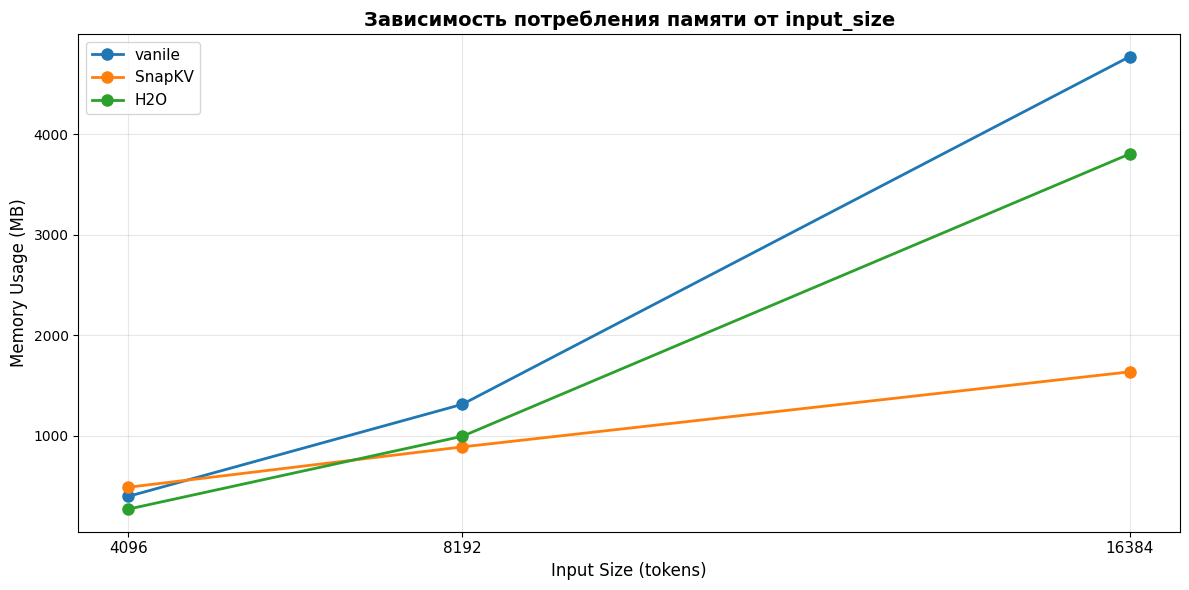

In [21]:
plt.figure(figsize=(12, 6))

for strategy in ['vanile', 'SnapKV', 'H2O']:
    subset = df[df['kv_cache_type'] == strategy]
    if strategy in ['SnapKV', 'H2O']:
        subset = subset[subset['cache_size'] == 512]
    subset = subset.sort_values('input_size')
    plt.plot(subset['input_size'], subset['memory_usage_mb'], marker='o', linewidth=2, markersize=8, label=strategy)

input_sizes = [4096, 8192, 16384]
plt.xticks(input_sizes, [f'{x}' for x in input_sizes], fontsize=11)

plt.xlabel('Input Size (tokens)', fontsize=12)
plt.ylabel('Memory Usage (MB)', fontsize=12)
plt.title('Зависимость потребления памяти от input_size', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
# plt.xscale('log')
plt.tight_layout()
plt.show()

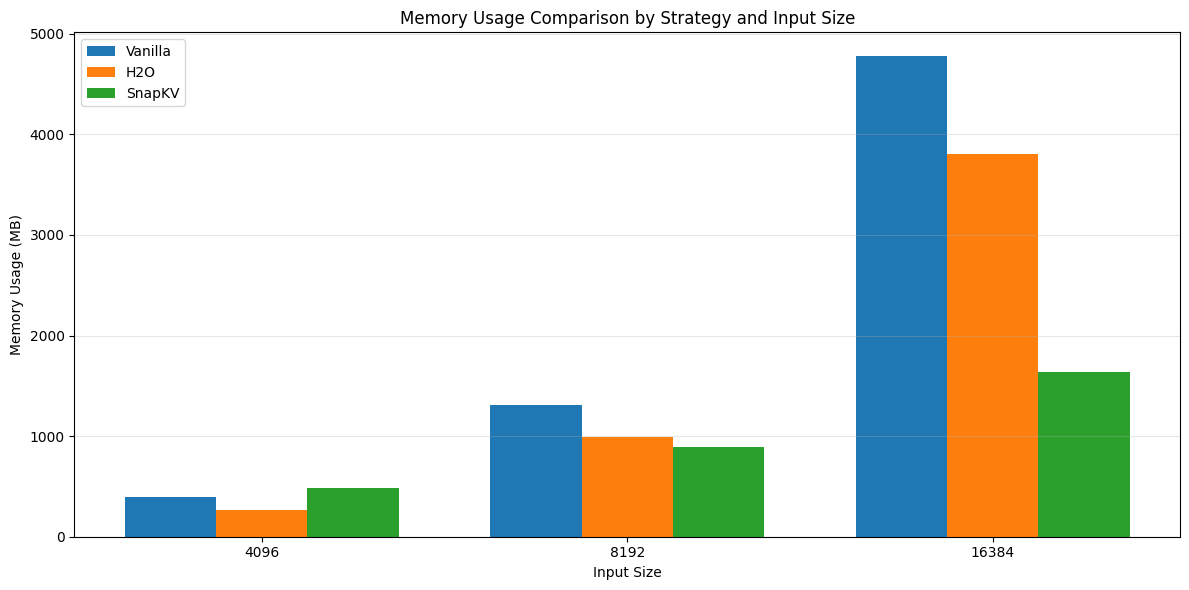

In [41]:
import numpy as np

plt.figure(figsize=(12, 6))

input_sizes = [4096, 8192, 16384]
strategies = ['Vanilla', 'H2O', 'SnapKV']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Собираем данные
data = {}
for strategy in strategies:
    data[strategy] = []
    for input_sz in input_sizes:
        if strategy == 'Vanilla':
            val = df[(df['kv_cache_type'] == 'vanile') & (df['input_size'] == input_sz)]['memory_usage_mb'].values
        else:
            val = df[(df['kv_cache_type'] == strategy) & (df['input_size'] == input_sz) & (df['cache_size'] == 512)]['memory_usage_mb'].values
        data[strategy].append(val[0] if len(val) > 0 else 0)

# Настройка grouped bar chart
x = np.arange(len(input_sizes))
width = 0.25
multiplier = 0

for strategy, color in zip(strategies, colors):
    offset = width * multiplier
    rects = plt.bar(x + offset, data[strategy], width, label=strategy, color=color)
    multiplier += 1

plt.xlabel('Input Size')
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage Comparison by Strategy and Input Size')
plt.xticks(x + width, input_sizes)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Cache size vs TPS

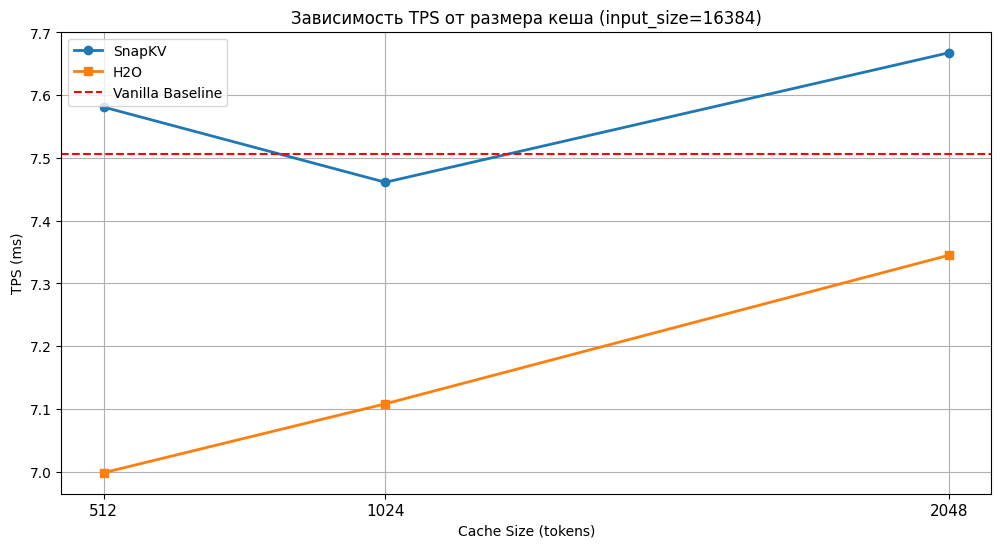

In [35]:
# Анализ влияния cache_size на latency
plt.figure(figsize=(12, 6))

# Для SnapKV
snapkv_data = df[(df['kv_cache_type'] == 'SnapKV') & (df['input_size'] == 16384)].sort_values('cache_size')
plt.plot(snapkv_data['cache_size'], snapkv_data['generation_speed'], 
         marker='o', label='SnapKV', linewidth=2)

# Для H2O
h2o_data = df[(df['kv_cache_type'] == 'H2O') & (df['input_size'] == 16384)].sort_values('cache_size')
plt.plot(h2o_data['cache_size'], h2o_data['generation_speed'], 
         marker='s', label='H2O', linewidth=2)

# Добавляем Vanilla как baseline (без ограничения кеша)
vanilla_latency = df[(df['kv_cache_type'] == 'vanile') & (df['input_size'] == 16384)]['generation_speed'].mean()
plt.axhline(y=vanilla_latency, color='red', linestyle='--', label='Vanilla Baseline')

cache_sizes = [512, 1024, 2048]
plt.xticks(cache_sizes, [f'{x}' for x in cache_sizes], fontsize=11)

plt.xlabel('Cache Size (tokens)')
plt.ylabel('TPS (ms)')
plt.title('Зависимость TPS от размера кеша (input_size=16384)')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
df_16384 = df[df['input_size'] == 16384].copy()

strategy_names = {
    'vanile': 'Vanilla',
    'SnapKV': 'SnapKV',
    'H2O': 'H2O'
}

df_16384['strategy_label'] = df_16384['kv_cache_type'].map(strategy_names)

df_16384.loc[df_16384['kv_cache_type'] == 'vanile', 'cache_size_display'] = 'full'
df_16384.loc[df_16384['kv_cache_type'] != 'vanile', 'cache_size_display'] = df_16384['cache_size'].astype(str)

df_16384 = df_16384.sort_values(['kv_cache_type', 'cache_size'])

result_table = df_16384[['strategy_label', 'cache_size_display', 'rougeL', 'bert_f1', 'generation_speed', 'decode_latency_ms', 'memory_usage_mb']].copy()

result_table.columns = ['Strategy', 'Cache Size', 'ROUGE-L', 'BERT-F1', 'Gen Speed (tok/s)', 'Decode Latency (ms)', 'Memory (MB)']

result_table['ROUGE-L'] = result_table['ROUGE-L'].round(4)
result_table['BERT-F1'] = result_table['BERT-F1'].round(4)
result_table['Gen Speed (tok/s)'] = result_table['Gen Speed (tok/s)'].round(3)
result_table['Decode Latency (ms)'] = result_table['Decode Latency (ms)'].round(2)
result_table['Memory (MB)'] = result_table['Memory (MB)'].round(1)

numeric_cols = ['ROUGE-L', 'BERT-F1', 'Gen Speed (tok/s)', 'Decode Latency (ms)', 'Memory (MB)']
best_rougel = result_table['ROUGE-L'].max()
best_bert = result_table['BERT-F1'].max()
best_speed = result_table['Gen Speed (tok/s)'].max()
best_latency = result_table['Decode Latency (ms)'].min()
best_memory = result_table['Memory (MB)'].min()


marked_table = result_table.copy()


marked_table['ROUGE-L'] = marked_table['ROUGE-L'].apply(
    lambda x: f"★ {x:.4f}" if isinstance(x, (int, float)) and x == best_rougel else f"{x:.4f}"
)
marked_table['BERT-F1'] = marked_table['BERT-F1'].apply(
    lambda x: f"★ {x:.4f}" if isinstance(x, (int, float)) and x == best_bert else f"{x:.4f}"
)
marked_table['Gen Speed (tok/s)'] = marked_table['Gen Speed (tok/s)'].apply(
    lambda x: f"★ {x:.3f}" if isinstance(x, (int, float)) and x == best_speed else f"{x:.3f}"
)
marked_table['Decode Latency (ms)'] = marked_table['Decode Latency (ms)'].apply(
    lambda x: f"★ {x:.2f}" if isinstance(x, (int, float)) and x == best_latency else f"{x:.2f}"
)
marked_table['Memory (MB)'] = marked_table['Memory (MB)'].apply(
    lambda x: f"★ {x:.1f}" if isinstance(x, (int, float)) and x == best_memory else f"{x:.1f}"
)

print(marked_table.to_string(index=False))


ТАБЛИЦА С МАРКЕРАМИ ЛУЧШИХ ЗНАЧЕНИЙ
Strategy Cache Size  ROUGE-L  BERT-F1 Gen Speed (tok/s) Decode Latency (ms) Memory (MB)
     H2O      512.0   0.1003   0.8057             6.998              142.89      3805.8
     H2O     1024.0   0.1154   0.8042             7.108              140.68      3808.7
     H2O     2048.0   0.1268   0.8097             7.345              136.15      3814.3
  SnapKV      512.0 ★ 0.1281   0.8047             7.581              122.77    ★ 1636.3
  SnapKV     1024.0   0.1189   0.7937             7.461              124.09      1649.8
  SnapKV     2048.0   0.1175   0.8086           ★ 7.668            ★ 118.78      1673.1
 Vanilla       full   0.1105 ★ 0.8227             7.507              134.52      4774.5


In [49]:
marked_table

,Strategy,Cache Size,ROUGE-L,BERT-F1,Gen Speed (tok/s),Decode Latency (ms),Memory (MB)
8,H2O,512.0,0.1003,0.8057,6.998,142.89,3805.8
9,H2O,1024.0,0.1154,0.8042,7.108,140.68,3808.7
10,H2O,2048.0,0.1268,0.8097,7.345,136.15,3814.3
3,SnapKV,512.0,★ 0.1281,0.8047,7.581,122.77,★ 1636.3
4,SnapKV,1024.0,0.1189,0.7937,7.461,124.09,1649.8
5,SnapKV,2048.0,0.1175,0.8086,★ 7.668,★ 118.78,1673.1
0,Vanilla,full,0.1105,★ 0.8227,7.507,134.52,4774.5


In [48]:
marked_table.to_excel('final_metrics.xlsx', index=False)